# 03 — Tokenizer comparison

**Phase 2, Part C.** Compare five tokenizers on our own held-out corpus and settle the
project's tokenizer choice (Part C decision point in `docs/phases/phase2_tokenizer.md`).

| Tokenizer | Vocab | Trained on |
|---|---|---|
| `scratch-bpe-8k` | 8,000 | ONE book (`marcus-aurelius-meditations.txt`) — pure-Python BPE from notebook 02 can't afford the full corpus |
| `hf-bpe-8k/16k/32k` | 8k / 16k / 32k | full S-tier corpus (books + dictionary, per D-006) via `tokenizers` (Rust) |
| `gpt2` | 50,257 | OpenAI's WebText — reference point, not trained on our data at all |

The `scratch-bpe-8k` vs `hf-bpe-8k` comparison isn't apples-to-apples (different training
sets), so treat it as "does our from-scratch implementation behave sensibly" rather than a
fair head-to-head; the real decision is among the three HF vocab sizes, with GPT-2 as an
external reference.

In [1]:
import json
import random
from pathlib import Path

from tokenizers import Tokenizer
from transformers import GPT2TokenizerFast

from llmlab.tokenizer.bpe_scratch import ByteLevelBPE

DATA = Path("../data/clean")
TOK_DIR = Path("../data/tokenized/tokenizers")

# --- load the four "real" tokenizers ---
hf_tokenizers = {
    f"hf-bpe-{v}": Tokenizer.from_file(str(TOK_DIR / f"hf_bpe_{v}" / "tokenizer.json"))
    for v in ["8k", "16k", "32k"]
}
gpt2_tok = GPT2TokenizerFast.from_pretrained("gpt2")

# --- retrain the scratch tokenizer from notebook 02 (single book, 8k vocab) ---
scratch_train_text = (DATA / "books" / "marcus-aurelius-meditations.txt").read_text()
scratch_tok = ByteLevelBPE(pretok_mode="gpt2")
scratch_tok.train(scratch_train_text, vocab_size=8000)

print("loaded:", list(hf_tokenizers) + ["gpt2", "scratch-bpe-8k"])

loaded: ['hf-bpe-8k', 'hf-bpe-16k', 'hf-bpe-32k', 'gpt2', 'scratch-bpe-8k']


## Held-out evaluation text

Books held out of ALL training (never seen by any tokenizer above, since even the HF
tokenizers were trained only on the `train` split): `boethius` + `epictetus`. Dictionary text
held out the same way: `val/dictionary_prose.txt`.

In [2]:
book_text = "\n".join(p.read_text() for p in sorted((DATA / "val" / "books").glob("*.txt")))
dict_text = (DATA / "val" / "dictionary_prose.txt").read_text()
print(f"held-out books:      {len(book_text.encode()):,} bytes, {len(book_text.split()):,} words")
print(f"held-out dictionary: {len(dict_text.encode()):,} bytes, {len(dict_text.split()):,} words")

held-out books:      309,257 bytes, 53,774 words
held-out dictionary: 320,735 bytes, 51,384 words


## Fertility and compression

**Fertility** = tokens per word (lower is better — fewer tokens to represent the same text,
so more of the model's fixed context window holds actual content). **Compression** =
bytes per token (higher is better, same reasoning from the byte side).

In [3]:
def encode_ids(name, tok, text):
    if name == "gpt2":
        return tok.encode(text)
    if name == "scratch-bpe-8k":
        return tok.encode(text)
    return tok.encode(text).ids


all_toks = {**hf_tokenizers, "gpt2": gpt2_tok, "scratch-bpe-8k": scratch_tok}

rows = []
for label, text in [("held-out books", book_text), ("held-out dictionary", dict_text)]:
    n_words = len(text.split())
    n_bytes = len(text.encode())
    for name, tok in all_toks.items():
        n_tokens = len(encode_ids(name, tok, text))
        rows.append({
            "corpus": label,
            "tokenizer": name,
            "tokens": n_tokens,
            "fertility (tok/word)": round(n_tokens / n_words, 3),
            "compression (bytes/tok)": round(n_bytes / n_tokens, 3),
        })

import pandas as pd
fertility_df = pd.DataFrame(rows)
fertility_df

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (79003 > 1024). Running this sequence through the model will result in indexing errors


,corpus,tokenizer,tokens,fertility (tok/word),compression (bytes/tok)
0,held-out books,hf-bpe-8k,86680,1.612,3.568
1,held-out books,hf-bpe-16k,80643,1.500,3.835
2,held-out books,hf-bpe-32k,76730,1.427,4.030
3,held-out books,gpt2,79003,1.469,3.914
4,held-out books,scratch-bpe-8k,89930,1.672,3.439
5,held-out dictionary,hf-bpe-8k,106262,2.068,3.018
6,held-out dictionary,hf-bpe-16k,99010,1.927,3.239
7,held-out dictionary,hf-bpe-32k,93260,1.815,3.439
8,held-out dictionary,gpt2,93997,1.829,3.412
9,held-out dictionary,scratch-bpe-8k,127783,2.487,2.510


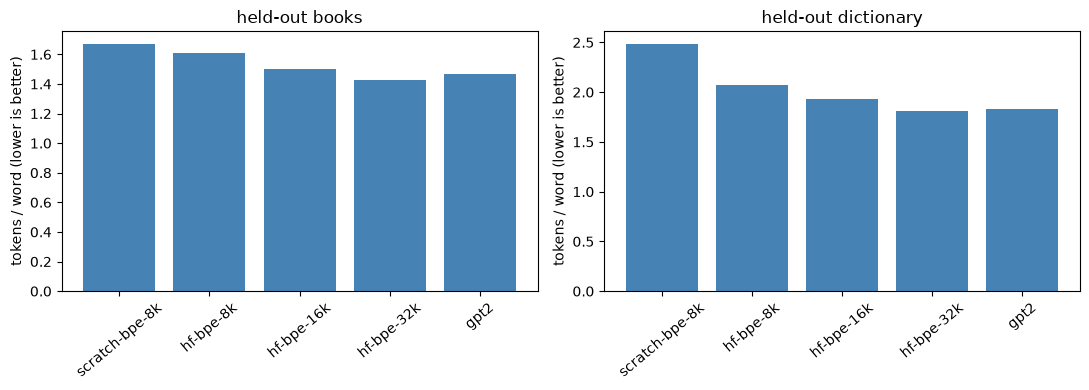

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
order = ["scratch-bpe-8k", "hf-bpe-8k", "hf-bpe-16k", "hf-bpe-32k", "gpt2"]
for ax, corpus in zip(axes, ["held-out books", "held-out dictionary"]):
    sub = fertility_df[fertility_df["corpus"] == corpus].set_index("tokenizer").loc[order]
    ax.bar(sub.index, sub["fertility (tok/word)"], color="steelblue")
    ax.set_title(corpus)
    ax.set_ylabel("tokens / word (lower is better)")
    ax.tick_params(axis="x", rotation=40)
fig.tight_layout()
plt.show()

## Vocab utilization

What fraction of each tokenizer's vocabulary actually gets used when encoding OUR held-out
text (books + dictionary combined)? The three HF tokenizers were fit to our corpus, so we'd
expect most of their vocab to fire even on held-out text from the same distribution. GPT-2's
50k vocab was fit to WebText (news, forums, code, modern web text circa 2019) — a philosophy
and 1913-dictionary corpus should exercise a much smaller slice of it.

In [5]:
combined_val_text = book_text + "\n" + dict_text

util_rows = []
for name, tok in all_toks.items():
    ids = encode_ids(name, tok, combined_val_text)
    vocab_size = tok.vocab_size if hasattr(tok, "vocab_size") else tok.get_vocab_size()
    used = len(set(ids))
    util_rows.append({"tokenizer": name, "vocab_size": vocab_size, "ids_used": used,
                       "utilization": round(used / vocab_size, 4)})

util_df = pd.DataFrame(util_rows)
util_df

,tokenizer,vocab_size,ids_used,utilization
0,hf-bpe-8k,8000,7014,0.8768
1,hf-bpe-16k,16000,11400,0.7125
2,hf-bpe-32k,32000,15792,0.4935
3,gpt2,50257,15376,0.3059
4,scratch-bpe-8k,8000,5715,0.7144


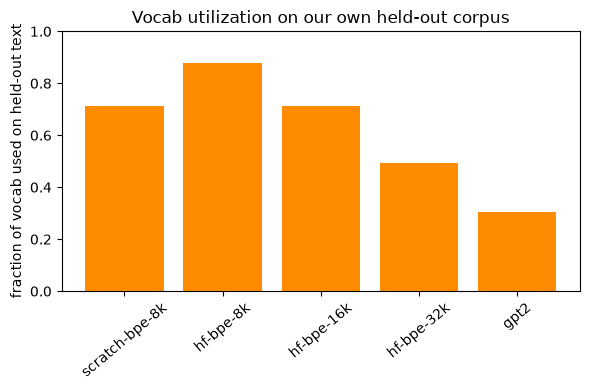

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_df = util_df.set_index("tokenizer").loc[order]
ax.bar(plot_df.index, plot_df["utilization"], color="darkorange")
ax.set_ylabel("fraction of vocab used on held-out text")
ax.set_title("Vocab utilization on our own held-out corpus")
ax.tick_params(axis="x", rotation=40)
ax.set_ylim(0, 1)
fig.tight_layout()
plt.show()

## Rare-word handling

Twenty genuinely obscure headwords sampled (fixed seed) from the training dictionary —
long, uncommon words the tokenizers are unlikely to have earned a dedicated merge for. Shown
as raw sub-token pieces (`Ġ` marks a leading space in GPT-2's byte-level display convention —
`tokens.decode()` would give back readable text; the point here is *how many pieces* and
*where the splits fall*).

In [7]:
with open(DATA / "dictionary.jsonl") as f:
    all_words = [json.loads(line)["word"] for line in f]
obscure_candidates = [w for w in all_words if w.isalpha() and len(w) >= 12]
obscure_words = random.Random(42).sample(obscure_candidates, 20)
print(obscure_words)

['Professional', 'Chartography', 'Alternativeness', 'Subscription', 'Entomostracous', 'Disquietment', 'Dilettanteish', 'comparability', 'Subcommittee', 'Catallactics', 'Residentiary', 'Subperiosteal', 'Oophorectomy', 'Boisterousness', 'Pharmaceutist', 'Interanimate', 'Anathematization', 'Anachoretical', 'Cabinetmaking', 'Dialectician']


In [8]:
def token_pieces(name, tok, word):
    if name == "gpt2":
        return tok.tokenize(word)
    if name == "scratch-bpe-8k":
        ids = tok.encode(word)
        return [tok.vocab[i].decode("utf-8", errors="replace") for i in ids]
    return tok.encode(word).tokens


rare_rows = []
for word in obscure_words:
    row = {"word": word}
    for name, tok in all_toks.items():
        pieces = token_pieces(name, tok, word)
        row[name] = " | ".join(pieces)
        row[f"{name}_n"] = len(pieces)
    rare_rows.append(row)

rare_df = pd.DataFrame(rare_rows)
rare_df

,word,hf-bpe-8k,hf-bpe-8k_n,hf-bpe-16k,hf-bpe-16k_n,hf-bpe-32k,hf-bpe-32k_n,gpt2,gpt2_n,scratch-bpe-8k,scratch-bpe-8k_n
0,Professional,Pro | f | ess | ion | al,5,Pro | f | ession | al,4,Prof | ession | al,3,Professional,1,Pro | f | ess | ion | al,5
1,Chartography,Ch | ar | to | gra | phy,5,Char | to | gra | phy,4,Char | to | graphy,3,Chart | ography,2,Char | to | gra | ph | y,5
2,Alternativeness,Al | tern | at | iveness,4,Al | tern | at | iveness,4,Al | tern | ativeness,3,Altern | at | iveness,3,A | l | tern | at | iv | eness,6
3,Subscription,Sub | s | cription,3,Sub | s | cription,3,Sub | s | cription,3,Sub | scription,2,S | ub | sc | ri | ption,5
4,Entomostracous,E | nt | om | ost | rac | ous,6,Ent | om | ost | rac | ous,5,Ent | om | ost | rac | ous,5,Ent | om | ost | rac | ous,5,E | n | to | most | rac | ous,6
5,Disquietment,Dis | qu | iet | ment,4,Dis | quiet | ment,3,Dis | quiet | ment,3,Dis | quiet | ment,3,D | is | qu | iet | ment,5
6,Dilettanteish,D | ile | t | t | ant | e | ish,7,D | ile | tt | ante | ish,5,D | ile | tt | ante | ish,5,D | ile | tt | ante | ish,5,D | ile | t | t | ant | e | ish,7
7,comparability,com | par | ability,3,compar | ability,2,compar | ability,2,com | par | ability,3,com | par | ability,3
8,Subcommittee,Sub | comm | it | te | e,5,Sub | comm | it | tee,4,Sub | commit | tee,3,Sub | committee,2,S | ub | comm | itt | e | e,6
9,Catallactics,C | at | all | act | ics,5,Cat | all | act | ics,4,Cat | all | act | ics,4,Cat | all | act | ics,4,C | at | all | act | ics,5


In [9]:
# average pieces-per-word across the 20 obscure headwords, one number per tokenizer
rare_df[[c for c in rare_df.columns if c.endswith("_n")]].mean().round(2)

hf-bpe-8k_n         4.40
hf-bpe-16k_n        3.80
hf-bpe-32k_n        3.45
gpt2_n              3.45
scratch-bpe-8k_n    5.10
dtype: float64

## Numbers and punctuation

GPT-2's byte-level BPE deliberately does NOT merge digit runs with letters, and its
pre-tokenizer regex has a dedicated numeric branch — but it still doesn't guarantee one
token per digit for long numbers. Compare a string with mixed numbers/currency/percent
punctuation.

In [10]:
numeric_toy = "In 1834 it cost $12.50, roughly 45.6% more than 1801's price of $8.99."
for name, tok in all_toks.items():
    pieces = token_pieces(name, tok, numeric_toy)
    print(f"{name:15s} (n={len(pieces):2d}): {pieces}")

hf-bpe-8k       (n=33): ['In', 'Ġ18', '34', 'Ġit', 'Ġcost', 'Ġ', '$', '12', '.', '50', ',', 'Ġrough', 'ly', 'Ġ4', '5', '.', '6', '%', 'Ġmore', 'Ġthan', 'Ġ18', '0', '1', "'s", 'Ġprice', 'Ġof', 'Ġ', '$', '8', '.', '9', '9', '.']
hf-bpe-16k      (n=32): ['In', 'Ġ18', '34', 'Ġit', 'Ġcost', 'Ġ', '$', '12', '.', '50', ',', 'Ġrough', 'ly', 'Ġ45', '.', '6', '%', 'Ġmore', 'Ġthan', 'Ġ18', '0', '1', "'s", 'Ġprice', 'Ġof', 'Ġ', '$', '8', '.', '9', '9', '.']
hf-bpe-32k      (n=27): ['In', 'Ġ18', '34', 'Ġit', 'Ġcost', 'Ġ$', '12', '.', '50', ',', 'Ġroughly', 'Ġ45', '.', '6', '%', 'Ġmore', 'Ġthan', 'Ġ180', '1', "'s", 'Ġprice', 'Ġof', 'Ġ$', '8', '.', '99', '.']
gpt2            (n=27): ['In', 'Ġ18', '34', 'Ġit', 'Ġcost', 'Ġ$', '12', '.', '50', ',', 'Ġroughly', 'Ġ45', '.', '6', '%', 'Ġmore', 'Ġthan', 'Ġ18', '01', "'s", 'Ġprice', 'Ġof', 'Ġ$', '8', '.', '99', '.']
scratch-bpe-8k  (n=34): ['In', ' 18', '34', ' it', ' c', 'ost', ' ', '$', '12', '.', '5', '0', ',', ' roughly', ' 4', '5', '.', '6', '%', ' more

## The embedding-table trade-off

A bigger vocab means shorter sequences (good) but a bigger embedding table (bad, at this
model scale). Illustrative math at `d_model=768` (a common choice for ~100M-param GPT-2-style
models — phase 3 will make the real call): input embedding is `vocab_size x d_model`; the
output/unembedding projection is the same shape, either tied to the input embedding (GPT-2's
choice, one copy) or trained separately (two copies).

In [11]:
D_MODEL = 768
TARGET_TOTAL_PARAMS = 100_000_000

embed_rows = []
for name, vocab in [("hf-bpe-8k", 8000), ("hf-bpe-16k", 16000), ("hf-bpe-32k", 32000), ("gpt2-50k", 50257)]:
    one_table = vocab * D_MODEL
    embed_rows.append({
        "tokenizer": name,
        "vocab_size": vocab,
        "one_embed_table": one_table,
        "tied (1 table)": one_table,
        "tied % of 100M model": round(100 * one_table / TARGET_TOTAL_PARAMS, 1),
        "untied (2 tables)": one_table * 2,
        "untied % of 100M model": round(100 * one_table * 2 / TARGET_TOTAL_PARAMS, 1),
    })
pd.DataFrame(embed_rows)

,tokenizer,vocab_size,one_embed_table,tied (1 table),tied % of 100M model,untied (2 tables),untied % of 100M model
0,hf-bpe-8k,8000,6144000,6144000,6.1,12288000,12.3
1,hf-bpe-16k,16000,12288000,12288000,12.3,24576000,24.6
2,hf-bpe-32k,32000,24576000,24576000,24.6,49152000,49.2
3,gpt2-50k,50257,38597376,38597376,38.6,77194752,77.2


At 32k vocab and `d_model=768`, an untied embedding+unembedding pair is ~49M params — roughly
**half** of a 100M-param budget spent purely on the vocabulary projection, before a single
transformer block. Weight-tying (GPT-2's approach) halves that, and is close to free
architecturally, but the trade-off doesn't vanish: it's now one large low-rank-ish matrix
pulling double duty in both directions, and it still eats disproportionately more of the
budget at 32k than at 8k or 16k.

## Verdict

- **Fertility/compression**: 8k -> 16k -> 32k on held-out books is 1.612 -> 1.500 -> 1.427
  tok/word. The 8k->16k step buys a 7.0% fertility improvement; the 16k->32k step only buys
  another 4.9% on top of that — clearly diminishing returns, most of the win is already
  captured by 16k.
- **Vocab utilization**: on our own held-out text, hf-bpe-8k uses 87.7% of its vocab,
  hf-bpe-16k 71.3%, hf-bpe-32k only **49.3%** — at 32k, roughly half the learned merges never
  fire outside their specific training documents. GPT-2's 50k vocab uses just 30.6% here,
  confirming it is a poor domain fit for a philosophy/dictionary corpus.
- **Rare words**: average pieces needed for the 20 obscure dictionary headwords: 8k=4.40,
  16k=3.80, 32k=3.45 (tied with GPT-2's 50k). Again the 8k->16k step (-0.60 pieces) captures
  most of the benefit; 16k->32k only adds another -0.35.
- **Embedding cost**: at an illustrative `d_model=768`, the embedding+unembedding cost is
  6.1-12.3% of a 100M-param budget at 8k, 12.3-24.6% at 16k, and **24.6-49.2% at 32k**
  (tied/untied). 32k risks spending up to half the entire parameter budget on the vocabulary
  projection alone, for a fertility/rare-word gain that's already mostly captured by 16k.

**Decision (logged as D-014 in `docs/DECISIONS.md`):** **HF byte-level BPE, 16k vocab** is
the project's tokenizer, chosen by the user after reviewing the numbers above — it captures
most of 32k's fertility and rare-word benefit at roughly half the embedding-table cost, and
avoids 32k's utilization problem (half its vocab going unused on our own held-out text).
`data/tokenized/hf_bpe_16k/{train,val}.bin` is the corpus used from phase 3 onward.